# 电商用户价值分层与精准营销策略分析

本 Notebook 基于 `user_personalized_features.csv` 完成：

- 传统 RFM 用户价值评分
- 优化 RFM-I 模型：新增意向度、转化摩擦、活跃连接度、购买力背景
- 用户分层画像与精准营销建议
- 传统 RFM 与优化 RFM 的 ROI 对比实验
- 可视化：柱状图、散点图、折线/柱状对比图、热力图


In [2]:
!pip install seaborn
!pip install IPython
!pip install matplotlib
!pip install pandas
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

sns.set_theme(style="whitegrid")

# 中文字体设置：Windows/Jupyter 常见字体优先
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Arial Unicode MS",
]
plt.rcParams["axes.unicode_minus"] = False


def show_fig(fig=None):
    """PyCharm/Jupyter ?????????? show_fig() ???"""
    if fig is None:
        fig = plt.gcf()
    display(fig)
    plt.close(fig)

DATA_PATH = Path(r"D:/archive/user_personalized_features.csv")

# 如果网页 Jupyter 无法访问 D 盘，可以把 csv 上传到 Notebook 同目录，然后启用下面这行：
# DATA_PATH = Path("user_personalized_features.csv")

OUT_DIR = Path("outputs_jupyter")
OUT_DIR.mkdir(exist_ok=True)

DATA_PATH


   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/7.8 MB 1.5 MB/s eta 0:00:05
   -- --------------------

WindowsPath('D:/archive/user_personalized_features.csv')

## 1. 读取数据与基础检查


In [3]:
df_raw = pd.read_csv(DATA_PATH)
df_raw = df_raw.loc[:, ~df_raw.columns.str.contains(r"^Unnamed|^$", regex=True)]

print("数据规模：", df_raw.shape)
display(df_raw.head())
display(df_raw.describe(include="all").T)


数据规模： (1000, 14)


,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,1000,1000,#1000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1000.0,NaN,NaN,NaN,40.986,13.497852,18.0,29.0,42.0,52.0,64.0
Gender,1000,2,Male,526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,1000,3,Suburban,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,1000.0,NaN,NaN,NaN,81304.732,37363.972753,20155.0,48715.5,81042.0,112694.5,149951.0
Interests,1000,5,Sports,213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last_Login_Days_Ago,1000.0,NaN,NaN,NaN,15.586,8.205604,1.0,8.0,16.0,23.0,29.0
Purchase_Frequency,1000.0,NaN,NaN,NaN,4.631,2.837762,0.0,2.0,5.0,7.0,9.0
Average_Order_Value,1000.0,NaN,NaN,NaN,104.039,54.873569,10.0,58.0,105.0,150.0,199.0
Total_Spending,1000.0,NaN,NaN,NaN,2552.957,1420.985048,112.0,1271.75,2542.0,3835.5,4999.0


In [4]:
df = df_raw.copy()

bool_map = {"True": True, "False": False, True: True, False: False}
df["Newsletter_Subscription"] = df["Newsletter_Subscription"].map(bool_map).astype(bool)

numeric_cols = [
    "Age",
    "Income",
    "Last_Login_Days_Ago",
    "Purchase_Frequency",
    "Average_Order_Value",
    "Total_Spending",
    "Time_Spent_on_Site_Minutes",
    "Pages_Viewed",
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=numeric_cols).reset_index(drop=True)

print("清洗后数据规模：", df.shape)
print("缺失值：")
display(df.isna().sum())


清洗后数据规模： (1000, 14)
缺失值：


User_ID                        0
Age                            0
Gender                         0
Location                       0
Income                         0
Interests                      0
Last_Login_Days_Ago            0
Purchase_Frequency             0
Average_Order_Value            0
Total_Spending                 0
Product_Category_Preference    0
Time_Spent_on_Site_Minutes     0
Pages_Viewed                   0
Newsletter_Subscription        0
dtype: int64

## 2. 构建传统 RFM 与优化 RFM-I 指标

传统 RFM：

- R：最近登录越近越高
- F：购买频次越高越高
- M：总消费越高越高

新增因子：

- **意向度 I-score** = 停留时长分位分 * 0.5 + 浏览页数分位分 * 0.5
- **转化摩擦系数** = 浏览页数 / (购买次数 + 1)
- **活跃连接度** = 订阅状态 + 最近登录天数
- **购买力背景** = 收入分层 + 消费/收入比例，只做标签，不进入主评分


In [5]:
def pct_score(series: pd.Series, higher_is_better: bool = True) -> pd.Series:
    """返回 0-100 分位分。"""
    rank = series.rank(method="average", pct=True, ascending=True)
    if higher_is_better:
        return rank * 100
    return (1 - rank) * 100


def tier_by_quantile(series: pd.Series, labels: list[str]) -> pd.Series:
    return pd.qcut(series.rank(method="first"), q=len(labels), labels=labels)


def active_connection(row: pd.Series) -> str:
    subscribed = bool(row["Newsletter_Subscription"])
    days = row["Last_Login_Days_Ago"]
    if subscribed and days <= 7:
        return "高连接-订阅且7天内登录"
    if (not subscribed) and days <= 7:
        return "中连接-未订阅但7天内登录"
    if (subscribed and days >= 30) or days > 30:
        return "低连接-名义忠诚/不活跃"
    if subscribed:
        return "名义忠诚-需激活"
    return "弱连接-未订阅且近期未登录"


# 传统 RFM
df["R_Score"] = pct_score(df["Last_Login_Days_Ago"], higher_is_better=False)
df["F_Score"] = pct_score(df["Purchase_Frequency"], higher_is_better=True)
df["M_Score"] = pct_score(df["Total_Spending"], higher_is_better=True)
df["RFM_Score"] = 0.35 * df["R_Score"] + 0.30 * df["F_Score"] + 0.35 * df["M_Score"]

# 新增：意向度
df["Time_Score"] = pct_score(df["Time_Spent_on_Site_Minutes"], higher_is_better=True)
df["Pages_Score"] = pct_score(df["Pages_Viewed"], higher_is_better=True)
df["I_Score"] = 0.5 * df["Time_Score"] + 0.5 * df["Pages_Score"]

# 新增：转化摩擦
df["Conversion_Friction"] = df["Pages_Viewed"] / (df["Purchase_Frequency"] + 1)
df["Friction_Score"] = pct_score(df["Conversion_Friction"], higher_is_better=True)

# 新增：活跃连接度
df["Active_Connection"] = df.apply(active_connection, axis=1)

# 新增：购买力背景，只做标签
df["Income_Pct"] = pct_score(df["Income"], higher_is_better=True)
df["Income_Tier"] = tier_by_quantile(df["Income"], ["低收入", "中低收入", "中高收入", "高收入"])
df["Spend_Income_Ratio"] = df["Total_Spending"] / df["Income"]
df["Spend_Burden_Tier"] = tier_by_quantile(
    df["Spend_Income_Ratio"],
    ["低负担消费", "适中负担消费", "高负担消费", "超高负担消费"],
)
df["Purchasing_Power_Tag"] = df["Income_Tier"].astype(str) + "/" + df["Spend_Burden_Tier"].astype(str)

# 增强价值分
active_adj = df["Active_Connection"].map(
    {
        "高连接-订阅且7天内登录": 8,
        "中连接-未订阅但7天内登录": 5,
        "名义忠诚-需激活": 1,
        "弱连接-未订阅且近期未登录": -3,
        "低连接-名义忠诚/不活跃": -8,
    }
).fillna(0)

friction_adj = np.where(df["Friction_Score"] >= 75, -5, np.where(df["Friction_Score"] <= 25, 4, 0))

df["Enhanced_Value_Score"] = np.clip(
    0.55 * df["RFM_Score"]
    + 0.25 * df["I_Score"]
    + 0.20 * (100 - df["Friction_Score"])
    + active_adj
    + friction_adj,
    0,
    100,
)

display(
    df[
        [
            "User_ID",
            "RFM_Score",
            "I_Score",
            "Conversion_Friction",
            "Friction_Score",
            "Active_Connection",
            "Purchasing_Power_Tag",
            "Enhanced_Value_Score",
        ]
    ].head()
)


,User_ID,RFM_Score,I_Score,Conversion_Friction,Friction_Score,Active_Connection,Purchasing_Power_Tag,Enhanced_Value_Score
0,#1,70.3550,88.150,4.750000,55.55,高连接-订阅且7天内登录,低收入/超高负担消费,77.622750
1,#2,42.1450,76.600,5.000000,58.55,弱连接-未订阅且近期未登录,中高收入/低负担消费,47.619750
2,#3,31.8500,26.300,0.500000,4.30,名义忠诚-需激活,中高收入/高负担消费,48.232500
3,#4,55.3525,73.550,7.250000,72.25,弱连接-未订阅且近期未登录,中低收入/超高负担消费,51.381375
4,#5,81.3100,14.775,1.666667,18.90,高连接-订阅且7天内登录,中低收入/超高负担消费,76.634250


## 3. 用户分层规则


In [6]:
def segment_user(row: pd.Series) -> str:
    high_income = row["Income_Pct"] >= 75
    low_income = row["Income_Pct"] <= 40
    high_spend = row["M_Score"] >= 70
    low_spend = row["M_Score"] <= 45
    active_recent = row["Last_Login_Days_Ago"] <= 7
    inactive = row["R_Score"] <= 35
    high_intent = row["I_Score"] >= 70
    very_high_intent = row["I_Score"] >= 80
    high_friction = row["Friction_Score"] >= 70
    low_purchase = row["Purchase_Frequency"] <= df["Purchase_Frequency"].median()

    if high_income and high_spend and inactive:
        return "高潜流失客"
    if high_income and high_intent and low_spend and high_friction:
        return "纠结土豪"
    if very_high_intent and active_recent and low_purchase and low_spend:
        return "高潜观望者"
    if high_intent and low_income and low_spend and row["Last_Login_Days_Ago"] <= 15:
        return "隐形活跃者"
    if row["Enhanced_Value_Score"] >= 78 and row["R_Score"] >= 45:
        return "核心用户"
    if row["Enhanced_Value_Score"] >= 62 or (high_intent and active_recent):
        return "潜力用户"
    if row["R_Score"] <= 30 and row["RFM_Score"] >= 55:
        return "沉睡价值用户"
    if row["RFM_Score"] <= 35 and row["I_Score"] <= 45:
        return "低价值用户"
    return "一般用户"


df["Enhanced_Segment"] = df.apply(segment_user, axis=1)

segment_summary = (
    df.groupby("Enhanced_Segment")
    .agg(
        用户数=("User_ID", "count"),
        平均消费=("Total_Spending", "mean"),
        平均客单价=("Average_Order_Value", "mean"),
        平均收入=("Income", "mean"),
        平均意向分=("I_Score", "mean"),
        平均摩擦分=("Friction_Score", "mean"),
        平均增强价值分=("Enhanced_Value_Score", "mean"),
        最近登录天数=("Last_Login_Days_Ago", "mean"),
    )
    .sort_values("用户数", ascending=False)
    .round(2)
)

display(segment_summary)


,用户数,平均消费,平均客单价,平均收入,平均意向分,平均摩擦分,平均增强价值分,最近登录天数
Enhanced_Segment,,,,,,,,
一般用户,627,2393.73,104.35,79697.40,50.40,56.03,45.47,16.68
潜力用户,187,3194.65,104.34,83704.19,51.94,33.76,67.51,9.84
低价值用户,68,1172.76,98.54,83971.90,27.89,42.65,32.47,22.84
核心用户,34,3643.88,98.38,72581.03,53.63,27.96,81.41,4.29
高潜流失客,28,4273.89,114.68,126868.14,44.54,44.58,50.18,24.21
沉睡价值用户,23,4102.83,110.04,58787.61,45.31,35.25,55.69,24.57
隐形活跃者,16,1062.31,105.44,42306.06,78.80,76.18,48.56,8.88
纠结土豪,12,1212.33,93.42,133819.00,84.63,87.26,39.14,14.50
高潜观望者,5,1094.40,101.00,63358.00,90.22,85.93,53.12,5.40


## 4. 可视化一：分层用户数量柱状图


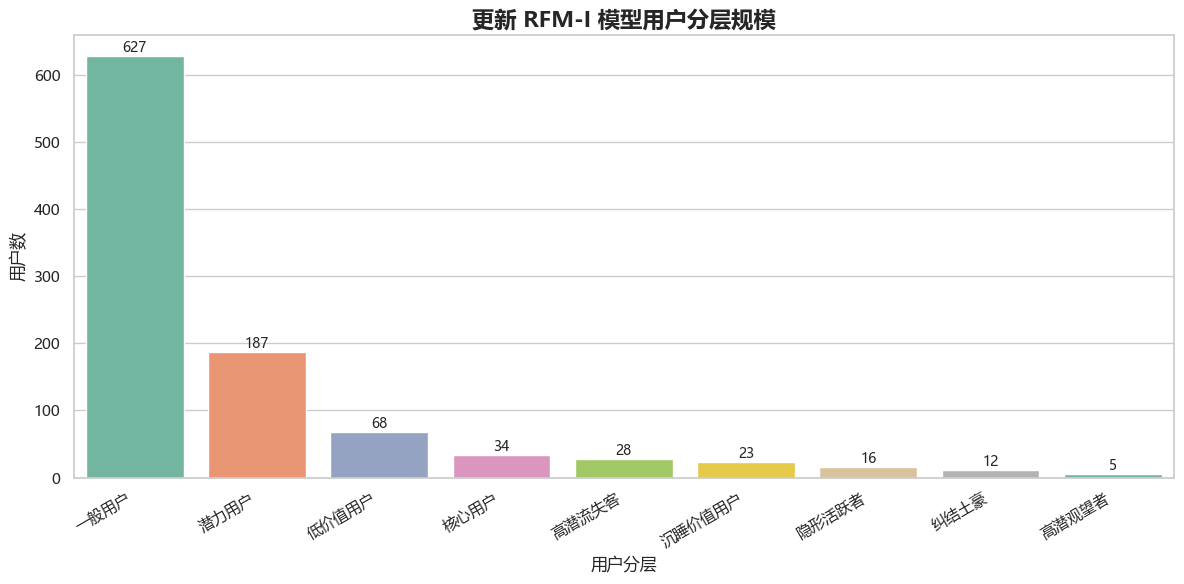

In [7]:
plt.figure(figsize=(12, 6))
order = segment_summary.index.tolist()
ax = sns.barplot(
    data=segment_summary.reset_index(),
    x="Enhanced_Segment",
    y="用户数",
    order=order,
    palette="Set2",
)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.title("更新 RFM-I 模型用户分层规模", fontsize=16, fontweight="bold")
plt.xlabel("用户分层")
plt.ylabel("用户数")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
show_fig()


## 5. 可视化二：各分层平均消费、收入、意向与摩擦对比


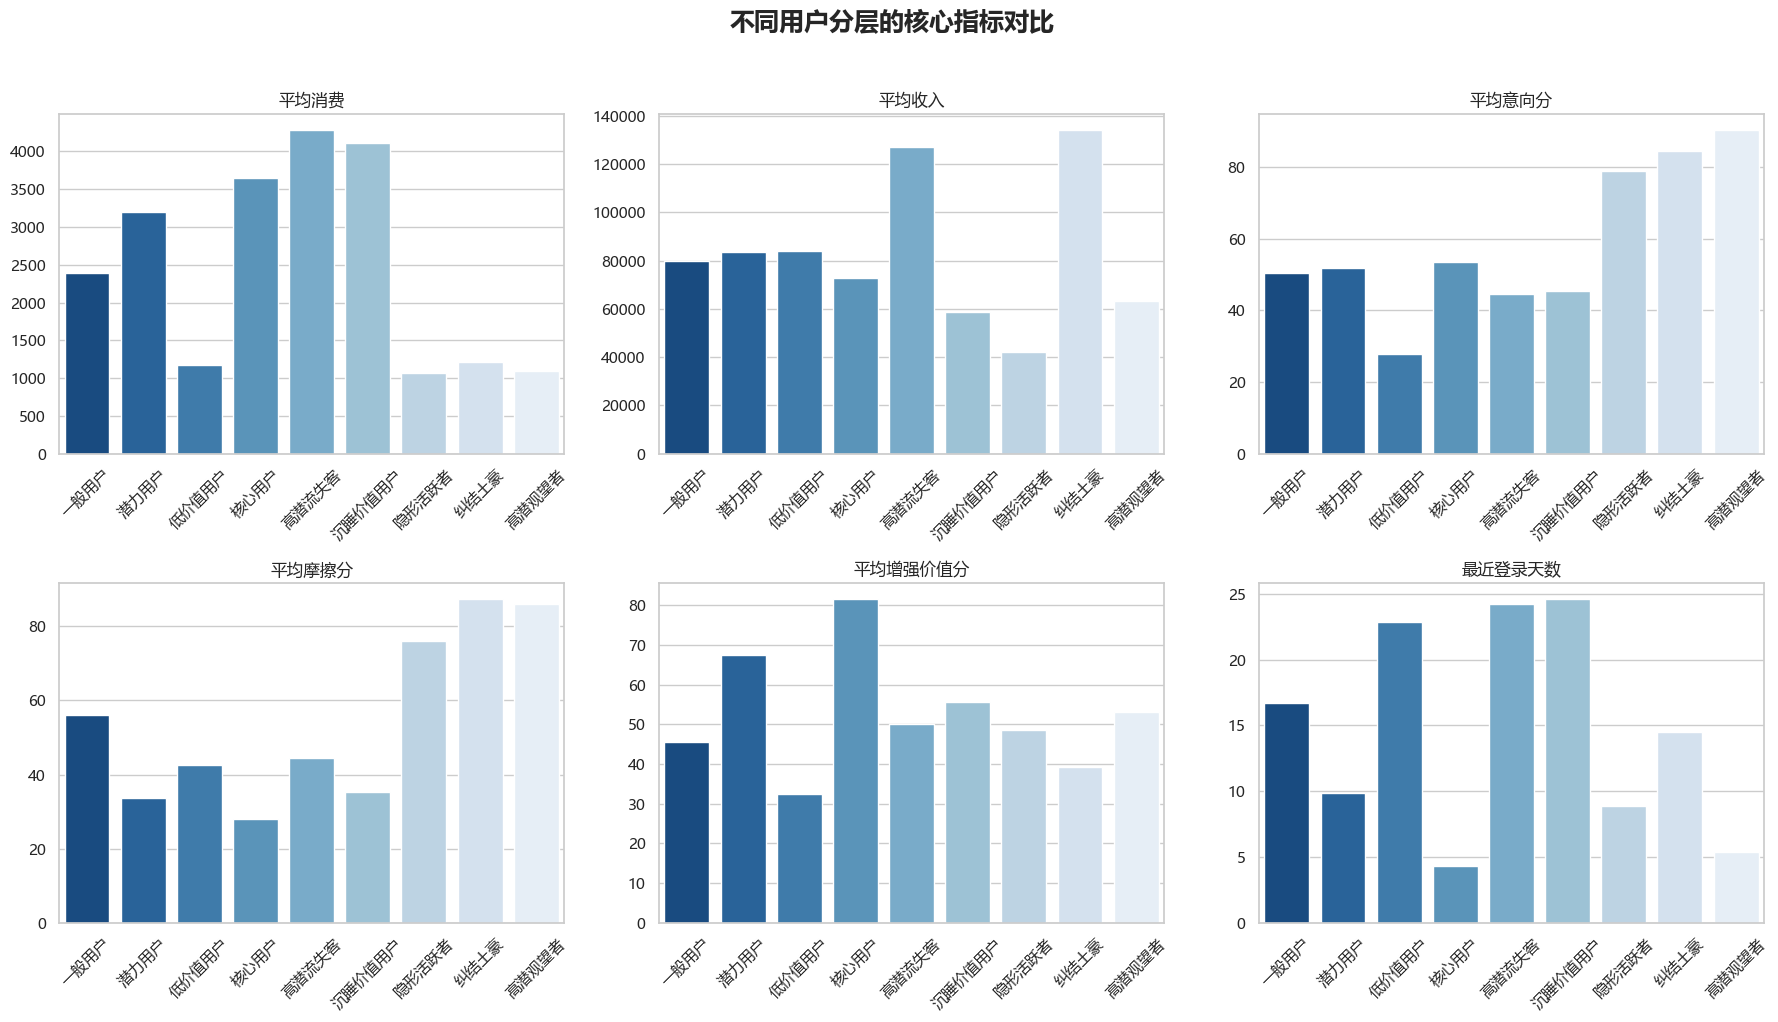

In [8]:
metric_df = segment_summary.reset_index().melt(
    id_vars="Enhanced_Segment",
    value_vars=["平均消费", "平均收入", "平均意向分", "平均摩擦分", "平均增强价值分", "最近登录天数"],
    var_name="指标",
    value_name="数值",
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metric_df["指标"].unique()):
    data = metric_df[metric_df["指标"] == metric]
    sns.barplot(data=data, x="Enhanced_Segment", y="数值", ax=ax, palette="Blues_r")
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("不同用户分层的核心指标对比", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
show_fig()


## 6. 可视化三：意向度 vs 消费金额散点图

这张图可以识别：

- 高意向低消费：潜在转化对象
- 高消费低意向：可能已经满足或即将流失
- 高意向高消费：核心经营对象


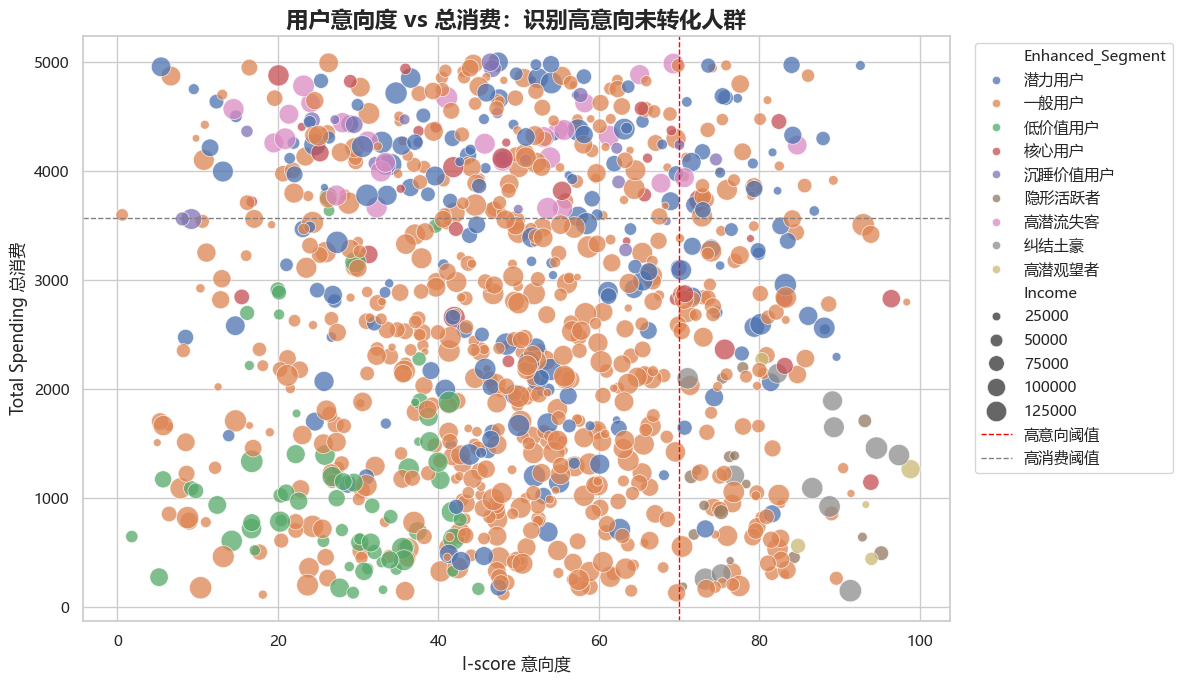

In [9]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x="I_Score",
    y="Total_Spending",
    hue="Enhanced_Segment",
    size="Income",
    sizes=(30, 260),
    alpha=0.75,
)
plt.axvline(70, color="red", linestyle="--", linewidth=1, label="高意向阈值")
plt.axhline(df["Total_Spending"].quantile(0.70), color="gray", linestyle="--", linewidth=1, label="高消费阈值")
plt.title("用户意向度 vs 总消费：识别高意向未转化人群", fontsize=16, fontweight="bold")
plt.xlabel("I-score 意向度")
plt.ylabel("Total Spending 总消费")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
show_fig()


## 7. 可视化四：转化摩擦 vs 意向度散点图

右上角代表：意向高、摩擦高，即“想买但纠结”。


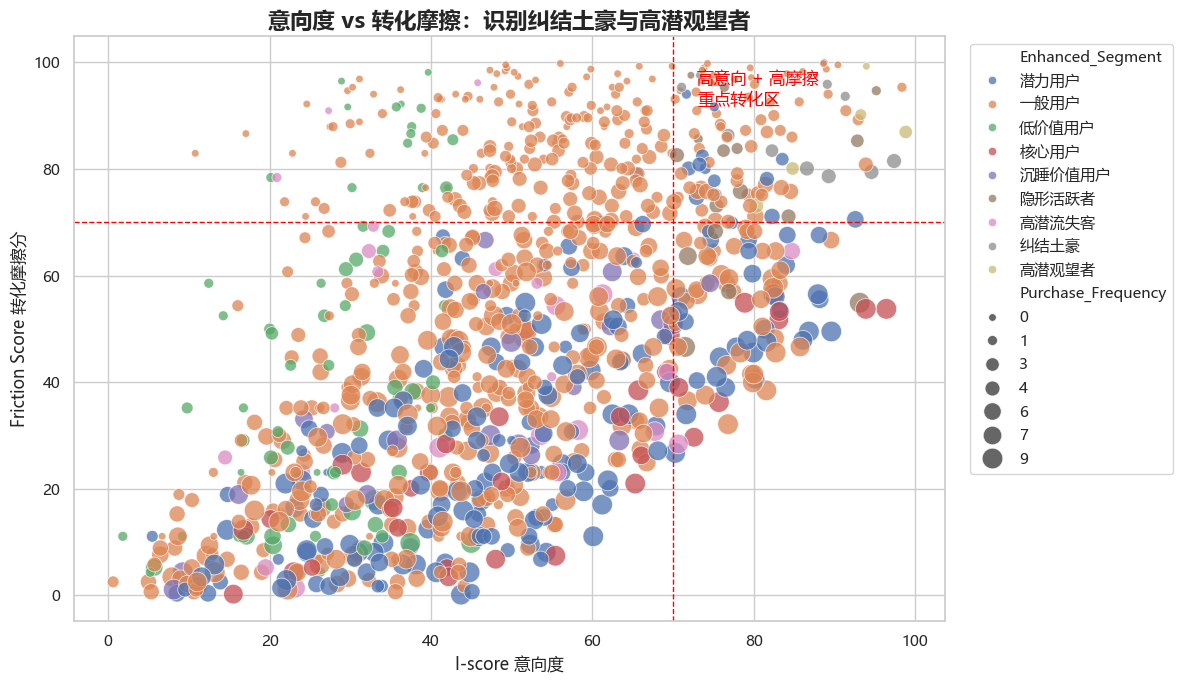

In [10]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x="I_Score",
    y="Friction_Score",
    hue="Enhanced_Segment",
    size="Purchase_Frequency",
    sizes=(30, 220),
    alpha=0.75,
)
plt.axvline(70, color="red", linestyle="--", linewidth=1)
plt.axhline(70, color="red", linestyle="--", linewidth=1)
plt.text(73, 92, "高意向 + 高摩擦\n重点转化区", color="red", fontsize=12)
plt.title("意向度 vs 转化摩擦：识别纠结土豪与高潜观望者", fontsize=16, fontweight="bold")
plt.xlabel("I-score 意向度")
plt.ylabel("Friction Score 转化摩擦分")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
show_fig()


## 8. 可视化五：RFM 分数与增强价值分对比

如果用户 RFM 不高但增强价值分高，说明传统模型可能低估了该用户。


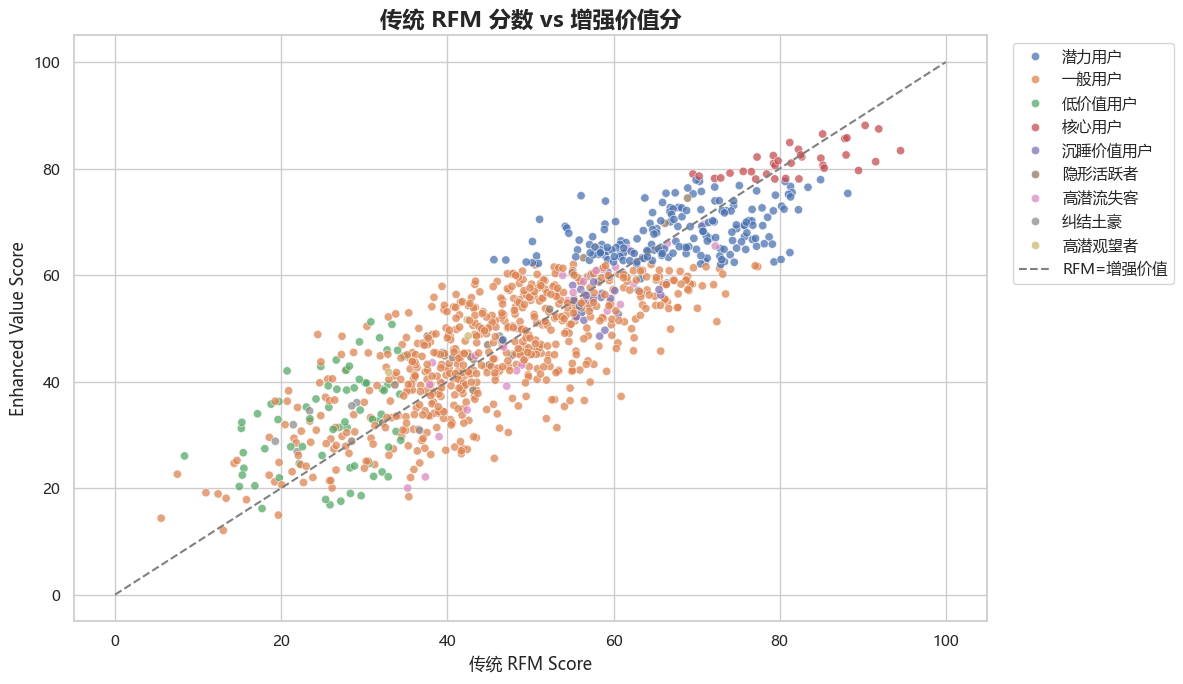

In [11]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x="RFM_Score",
    y="Enhanced_Value_Score",
    hue="Enhanced_Segment",
    alpha=0.75,
)
plt.plot([0, 100], [0, 100], color="gray", linestyle="--", label="RFM=增强价值")
plt.title("传统 RFM 分数 vs 增强价值分", fontsize=16, fontweight="bold")
plt.xlabel("传统 RFM Score")
plt.ylabel("Enhanced Value Score")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
show_fig()


## 9. 可视化六：购买力背景差异

同样消费金额，对不同收入用户意义不同。消费/收入比例越高，代表该消费对用户越“重”。


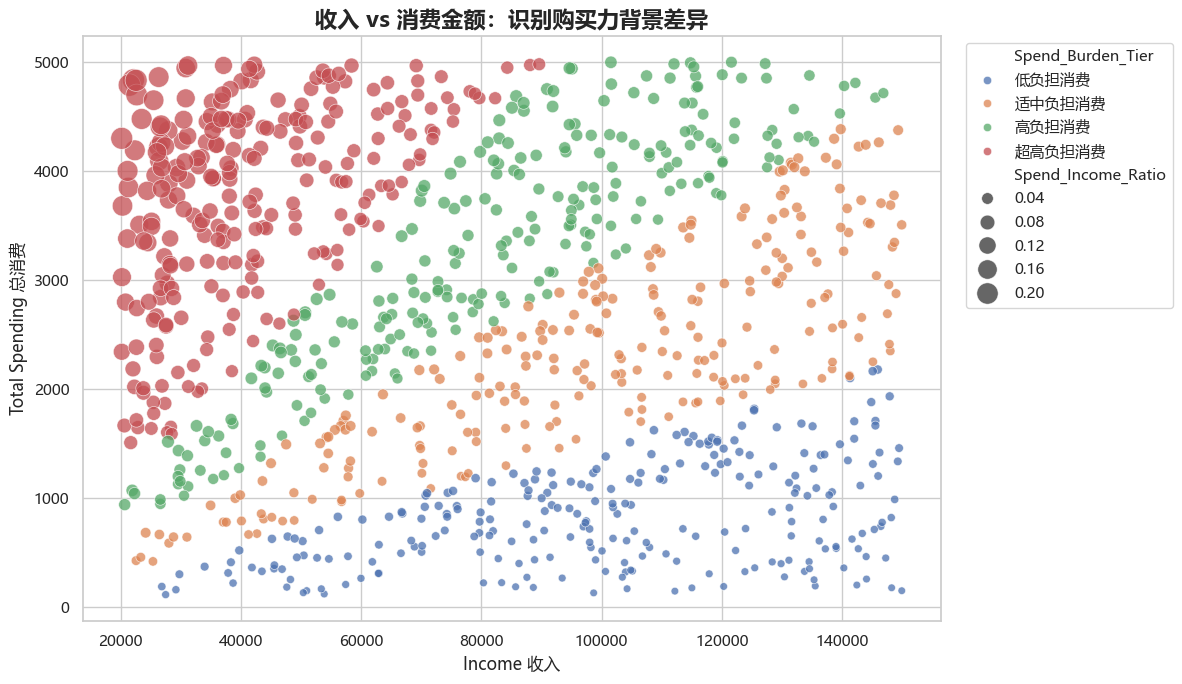

In [12]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df,
    x="Income",
    y="Total_Spending",
    hue="Spend_Burden_Tier",
    size="Spend_Income_Ratio",
    sizes=(30, 260),
    alpha=0.75,
)
plt.title("收入 vs 消费金额：识别购买力背景差异", fontsize=16, fontweight="bold")
plt.xlabel("Income 收入")
plt.ylabel("Total Spending 总消费")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
show_fig()


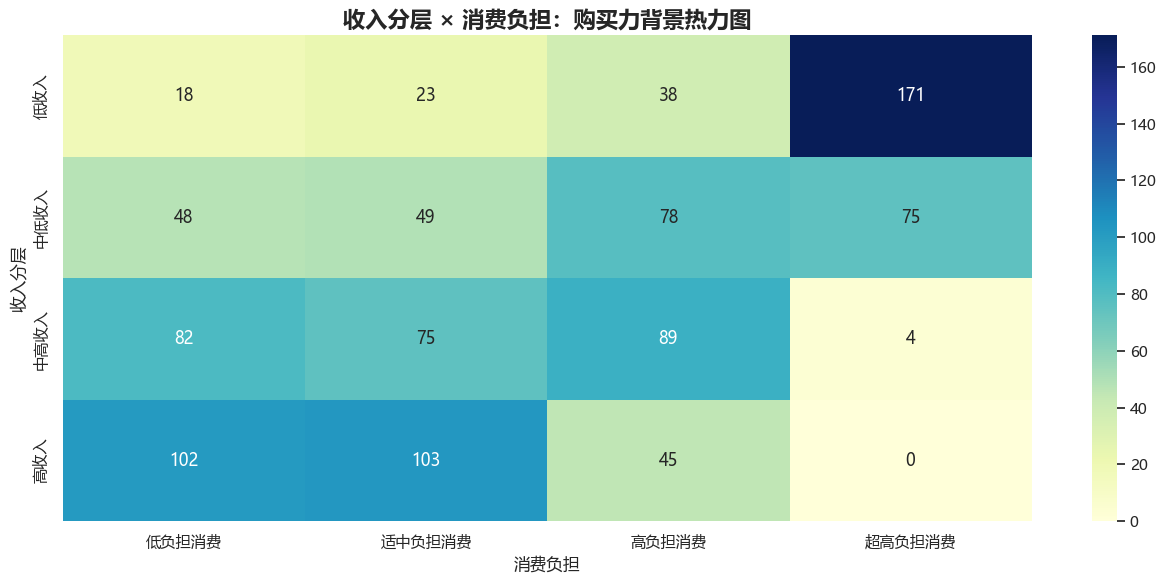

In [13]:
plt.figure(figsize=(13, 6))
income_spend = (
    df.groupby(["Income_Tier", "Spend_Burden_Tier"])
    .size()
    .reset_index(name="用户数")
)
pivot = income_spend.pivot(index="Income_Tier", columns="Spend_Burden_Tier", values="用户数").fillna(0)
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("收入分层 × 消费负担：购买力背景热力图", fontsize=16, fontweight="bold")
plt.xlabel("消费负担")
plt.ylabel("收入分层")
plt.tight_layout()
show_fig()


## 10. 分层营销建议


In [14]:
SEGMENT_STRATEGY = {
    "核心用户": "会员等级、专属新品、加价购、组合套装和复购周期提醒，提高客单价和复购频次。",
    "潜力用户": "围绕最近偏好类目做精准推荐，用阶梯满减和连续购买奖励把偶发消费变成习惯消费。",
    "高潜流失客": "优先召回并诊断流失原因，提供专属客服、个性化挽留券、新品优先体验。",
    "纠结土豪": "先降低决策成本：个性化榜单、同价位对比、专家推荐、套装方案，再给小额限时券。",
    "高潜观望者": "用低门槛首单券、足迹召回、购物车提醒和爆品推荐，促成首次或下一次购买。",
    "隐形活跃者": "鼓励分享裂变、评价晒单、内容互动；消费侧用低价爆品和拼团提升频次。",
    "沉睡价值用户": "轻触达测试兴趣，再根据点击和回访行为分层加码，避免一开始就高补贴。",
    "一般用户": "自动化运营和二次细分，用推荐、签到、常规促销培养偏好。",
    "低价值用户": "控制预算，低成本触达；只有出现高意向行为后再升级运营。",
}

strategy_table = segment_summary.reset_index()[["Enhanced_Segment", "用户数", "平均消费", "平均收入", "平均意向分", "平均摩擦分"]].copy()
strategy_table["营销建议"] = strategy_table["Enhanced_Segment"].map(SEGMENT_STRATEGY)
strategy_table = strategy_table.rename(columns={"Enhanced_Segment": "用户分层"})

display(strategy_table)


,用户分层,用户数,平均消费,平均收入,平均意向分,平均摩擦分,营销建议
0,一般用户,627,2393.73,79697.40,50.40,56.03,自动化运营和二次细分，用推荐、签到、常规促销培养偏好。
1,潜力用户,187,3194.65,83704.19,51.94,33.76,围绕最近偏好类目做精准推荐，用阶梯满减和连续购买奖励把偶发消费变成习惯消费。
2,低价值用户,68,1172.76,83971.90,27.89,42.65,控制预算，低成本触达；只有出现高意向行为后再升级运营。
3,核心用户,34,3643.88,72581.03,53.63,27.96,会员等级、专属新品、加价购、组合套装和复购周期提醒，提高客单价和复购频次。
4,高潜流失客,28,4273.89,126868.14,44.54,44.58,优先召回并诊断流失原因，提供专属客服、个性化挽留券、新品优先体验。
5,沉睡价值用户,23,4102.83,58787.61,45.31,35.25,轻触达测试兴趣，再根据点击和回访行为分层加码，避免一开始就高补贴。
6,隐形活跃者,16,1062.31,42306.06,78.80,76.18,鼓励分享裂变、评价晒单、内容互动；消费侧用低价爆品和拼团提升频次。
7,纠结土豪,12,1212.33,133819.00,84.63,87.26,先降低决策成本：个性化榜单、同价位对比、专家推荐、套装方案，再给小额限时券。
8,高潜观望者,5,1094.40,63358.00,90.22,85.93,用低门槛首单券、足迹召回、购物车提醒和爆品推荐，促成首次或下一次购买。


## 11. ROI 对比实验

实验设计：

- 传统 RFM 策略：给 RFM_Score 前 20% 用户发券
- 优化 RFM-I 策略：给核心用户、潜力用户、纠结土豪、高潜观望者、高潜流失客发券
- 两组触达人数一致，券面预算一致
- 原始数据没有真实营销曝光与转化结果，因此这里用行为代理模型估算预期 ROI


In [15]:
def roi_simulation(data: pd.DataFrame, coupon_value: float = 10.0, gross_margin: float = 0.35):
    target_n = max(1, int(np.floor(len(data) * 0.20)))
    budget = target_n * coupon_value

    active_bonus = data["Active_Connection"].map(
        {
            "高连接-订阅且7天内登录": 0.35,
            "中连接-未订阅但7天内登录": 0.25,
            "名义忠诚-需激活": 0.05,
            "弱连接-未订阅且近期未登录": -0.10,
            "低连接-名义忠诚/不活跃": -0.25,
        }
    ).fillna(0)

    segment_bonus = data["Enhanced_Segment"].map(
        {
            "纠结土豪": 0.55,
            "高潜观望者": 0.45,
            "高潜流失客": 0.40,
            "潜力用户": 0.25,
            "核心用户": 0.15,
            "隐形活跃者": 0.10,
        }
    ).fillna(0)

    affordability = np.clip(data["Income_Pct"] / 100, 0.05, 1.0)
    friction_penalty = np.clip(1 - data["Friction_Score"] / 180, 0.35, 1)

    logit = (
        -3.2
        + 0.018 * data["I_Score"]
        + 0.010 * data["F_Score"]
        + 0.008 * data["M_Score"]
        + active_bonus
        + 0.25 * affordability
    )
    base_prob = 1 / (1 + np.exp(-logit))

    coupon_uplift = np.clip(
        0.035
        * (0.55 + data["I_Score"] / 100)
        * friction_penalty
        * (0.75 + affordability)
        + segment_bonus / 20,
        0.005,
        0.18,
    )

    expected_90d_value = data["Average_Order_Value"] * (1 + data["Purchase_Frequency"] / 5)
    expected_coupon_cost = coupon_value * (base_prob + coupon_uplift)
    expected_incremental_revenue = coupon_uplift * expected_90d_value
    expected_incremental_profit = expected_incremental_revenue * gross_margin - expected_coupon_cost

    exp = data[
        [
            "User_ID",
            "RFM_Score",
            "Enhanced_Value_Score",
            "Enhanced_Segment",
            "Average_Order_Value",
        ]
    ].copy()
    exp["Base_Conversion_Proxy"] = base_prob
    exp["Coupon_Uplift_Proxy"] = coupon_uplift
    exp["Expected_Coupon_Cost"] = expected_coupon_cost
    exp["Expected_Incremental_Revenue"] = expected_incremental_revenue
    exp["Expected_Incremental_Profit"] = expected_incremental_profit

    traditional = exp.nlargest(target_n, "RFM_Score").assign(Experiment_Group="传统RFM-Top20%")

    optimized_pool = exp[
        exp["Enhanced_Segment"].isin(["核心用户", "潜力用户", "纠结土豪", "高潜观望者", "高潜流失客"])
    ]
    optimized = optimized_pool.nlargest(target_n, "Expected_Incremental_Profit").assign(Experiment_Group="优化RFM-核心与潜力")

    combined = pd.concat([traditional, optimized], ignore_index=True)

    summary = (
        combined.groupby("Experiment_Group")
        .agg(
            Target_Users=("User_ID", "count"),
            Budget=("User_ID", lambda s: len(s) * coupon_value),
            Avg_RFM=("RFM_Score", "mean"),
            Avg_Enhanced_Value=("Enhanced_Value_Score", "mean"),
            Avg_Base_Conversion=("Base_Conversion_Proxy", "mean"),
            Avg_Coupon_Uplift=("Coupon_Uplift_Proxy", "mean"),
            Expected_Coupon_Cost=("Expected_Coupon_Cost", "sum"),
            Expected_Incremental_Revenue=("Expected_Incremental_Revenue", "sum"),
            Expected_Incremental_Profit=("Expected_Incremental_Profit", "sum"),
        )
        .reset_index()
    )
    summary["Budget"] = budget
    summary["Expected_ROI"] = summary["Expected_Incremental_Profit"] / summary["Budget"]

    return combined, summary


roi_detail, roi_summary = roi_simulation(df)

display(roi_summary.round(4))


,Experiment_Group,Target_Users,Budget,Avg_RFM,Avg_Enhanced_Value,Avg_Base_Conversion,Avg_Coupon_Uplift,Expected_Coupon_Cost,Expected_Incremental_Revenue,Expected_Incremental_Profit,Expected_ROI
0,优化RFM-核心与潜力,200,2000.0,65.4051,65.8732,0.3105,0.0524,725.6640,2938.7781,302.9083,0.1515
1,传统RFM-Top20%,200,2000.0,73.2254,68.6470,0.3319,0.0442,752.3305,2169.3411,6.9389,0.0035


## 12. 可视化七：ROI 柱状 + 折线对比图


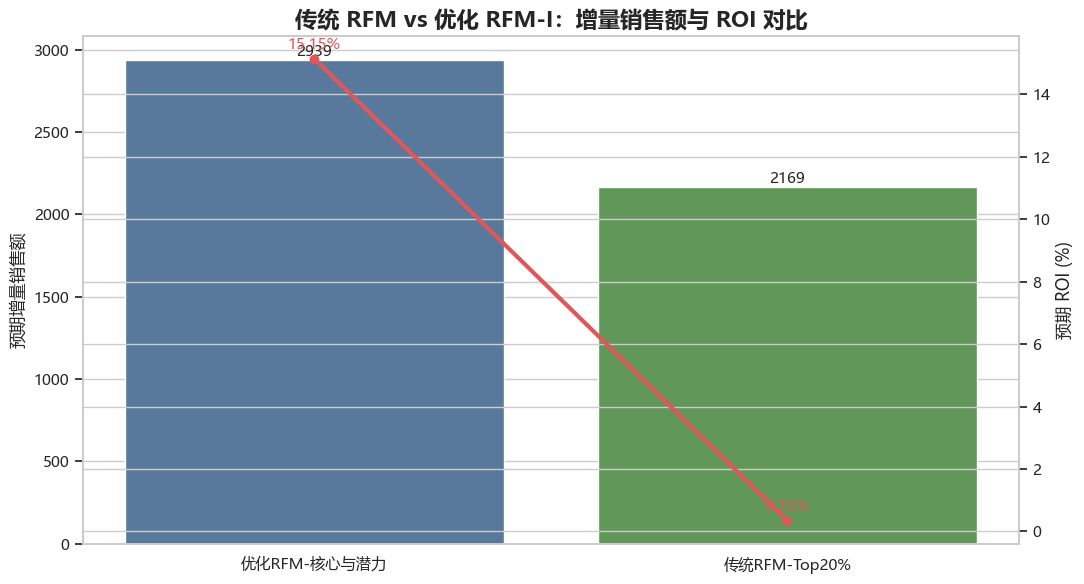

In [16]:
roi_plot = roi_summary.copy()
roi_plot["Expected_ROI_%"] = roi_plot["Expected_ROI"] * 100

fig, ax1 = plt.subplots(figsize=(11, 6))

bar = sns.barplot(
    data=roi_plot,
    x="Experiment_Group",
    y="Expected_Incremental_Revenue",
    ax=ax1,
    palette=["#4C78A8", "#59A14F"],
)
ax1.set_ylabel("预期增量销售额")
ax1.set_xlabel("")
ax1.set_title("传统 RFM vs 优化 RFM-I：增量销售额与 ROI 对比", fontsize=16, fontweight="bold")

for p in bar.patches:
    ax1.annotate(
        f"{p.get_height():.0f}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax2 = ax1.twinx()
ax2.plot(
    roi_plot["Experiment_Group"],
    roi_plot["Expected_ROI_%"],
    color="#E15759",
    marker="o",
    linewidth=3,
    label="预期 ROI",
)
ax2.set_ylabel("预期 ROI (%)")

for x, y in zip(roi_plot["Experiment_Group"], roi_plot["Expected_ROI_%"]):
    ax2.text(x, y + 0.3, f"{y:.2f}%", ha="center", color="#E15759", fontsize=11)

fig.tight_layout()
show_fig()


## 13. 可视化八：传统策略与优化策略触达人群差异


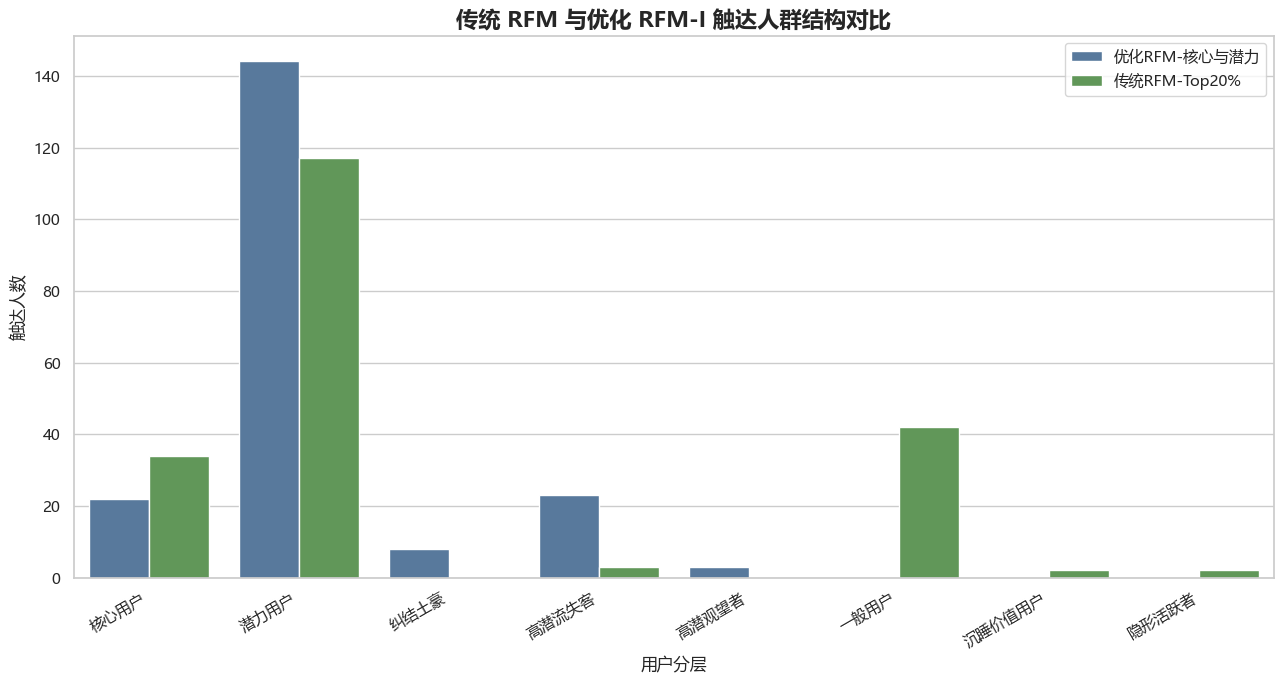

In [17]:
touch_detail = roi_detail.merge(
    df[["User_ID", "Enhanced_Segment"]],
    on=["User_ID", "Enhanced_Segment"],
    how="left",
)

touch_segment = (
    touch_detail.groupby(["Experiment_Group", "Enhanced_Segment"])
    .size()
    .reset_index(name="触达人数")
)

plt.figure(figsize=(13, 7))
sns.barplot(
    data=touch_segment,
    x="Enhanced_Segment",
    y="触达人数",
    hue="Experiment_Group",
    palette=["#4C78A8", "#59A14F"],
)
plt.title("传统 RFM 与优化 RFM-I 触达人群结构对比", fontsize=16, fontweight="bold")
plt.xlabel("用户分层")
plt.ylabel("触达人数")
plt.xticks(rotation=30, ha="right")
plt.legend(title="")
plt.tight_layout()
show_fig()


## 14. 结论


In [18]:
print("核心结论：")
print("1. 传统 RFM 更擅长找到历史消费高的人，但会漏掉高意向低消费、浏览多但未转化、以及高消费但正在流失的人。")
print("2. 优化 RFM-I 模型通过意向度、转化摩擦、活跃连接度和购买力背景标签，能识别更细的人群运营机会。")
print("3. 高潜观望者、纠结土豪、高潜流失客是传统 RFM 容易看不见，但很适合精准运营的人。")
print("4. ROI 对比中，优化策略把券投向更可能产生增量的人群，而不是只奖励历史高消费用户。")

display(roi_summary[["Experiment_Group", "Target_Users", "Budget", "Expected_Incremental_Revenue", "Expected_Incremental_Profit", "Expected_ROI"]].round(4))


核心结论：
1. 传统 RFM 更擅长找到历史消费高的人，但会漏掉高意向低消费、浏览多但未转化、以及高消费但正在流失的人。
2. 优化 RFM-I 模型通过意向度、转化摩擦、活跃连接度和购买力背景标签，能识别更细的人群运营机会。
3. 高潜观望者、纠结土豪、高潜流失客是传统 RFM 容易看不见，但很适合精准运营的人。
4. ROI 对比中，优化策略把券投向更可能产生增量的人群，而不是只奖励历史高消费用户。


,Experiment_Group,Target_Users,Budget,Expected_Incremental_Revenue,Expected_Incremental_Profit,Expected_ROI
0,优化RFM-核心与潜力,200,2000.0,2938.7781,302.9083,0.1515
1,传统RFM-Top20%,200,2000.0,2169.3411,6.9389,0.0035


## 15. 导出结果


In [19]:
df.to_csv(OUT_DIR / "user_value_segments_jupyter.csv", index=False, encoding="utf-8-sig")
segment_summary.to_csv(OUT_DIR / "segment_summary_jupyter.csv", encoding="utf-8-sig")
strategy_table.to_csv(OUT_DIR / "segment_marketing_strategy_jupyter.csv", index=False, encoding="utf-8-sig")
roi_summary.to_csv(OUT_DIR / "roi_experiment_summary_jupyter.csv", index=False, encoding="utf-8-sig")

print("已导出到：", OUT_DIR.resolve())


已导出到： C:\Users\Lenovo\OneDrive\文档\New project\outputs_jupyter
